# ANN_tensorflow

In [13]:
import tensorflow as tf 

In [14]:
import pandas as pd 

In [21]:
tf.keras.models.Sequential?


Init signature: tf.keras.models.Sequential(*args, **kwargs)
Docstring:     
`Sequential` groups a linear stack of layers into a `Model`.

Examples:

```python
model = keras.Sequential()
model.add(keras.Input(shape=(16,)))
model.add(keras.layers.Dense(8))

# Note that you can also omit the initial `Input`.
# In that case the model doesn't have any weights until the first call
# to a training/evaluation method (since it isn't yet built):
model = keras.Sequential()
model.add(keras.layers.Dense(8))
model.add(keras.layers.Dense(4))
# model.weights not created yet

# Whereas if you specify an `Input`, the model gets built
# continuously as you are adding layers:
model = keras.Sequential()
model.add(keras.Input(shape=(16,)))
model.add(keras.layers.Dense(8))
len(model.weights)  # Returns "2"

# When using the delayed-build pattern (no input shape specified), you can
# choose to manually build your model by calling
# `build(batch_input_shape)`:
model = keras.Sequential()
model.add(keras.layers.

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
import pandas as pd 
import seaborn as sns 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [4]:
data = sns.load_dataset('titanic')

In [5]:
data = data[['survived','pclass','age','sibsp','parch','fare']].dropna()

In [6]:
X = data.drop('survived' , axis= 1)
y = data['survived']

In [19]:
np.random.seed(42)
tensorflow.random.set_seed(42)


In [7]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size= 0.3, random_state= 42)


In [8]:
# model 
model = Sequential([
    
    Dense(64,activation= 'relu', input_shape = (X_train.shape[1],)),
    Dropout(0.5),

    Dense(32,activation= 'relu'),
    Dropout(0.5),

    Dense(1,activation= 'sigmoid'),
])


c:\Users\iamso\Desktop\BIOIN_Souvik\dl\dl_env2\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# compile model 

model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])

In [10]:
# train 

history = model.fit(X_train, y_train,validation_split= 0.2, epochs= 20 , batch_size= 32,verbose= 1)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5238 - loss: 4.7552 - val_accuracy: 0.6300 - val_loss: 0.8284
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4862 - loss: 4.1134 - val_accuracy: 0.6500 - val_loss: 0.9027
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5789 - loss: 3.1488 - val_accuracy: 0.7100 - val_loss: 0.8606
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5664 - loss: 2.6832 - val_accuracy: 0.7200 - val_loss: 0.8237
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5890 - loss: 2.3810 - val_accuracy: 0.7100 - val_loss: 0.8186
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5940 - loss: 2.0863 - val_accuracy: 0.7200 - val_loss: 0.8028
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5789 - loss: 2.3297 - val_accuracy: 0.7200 - val_loss: 0.7721
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5589 - loss: 2.3518 - val_accuracy: 0.7100 - val_lo

In [12]:
print(history)

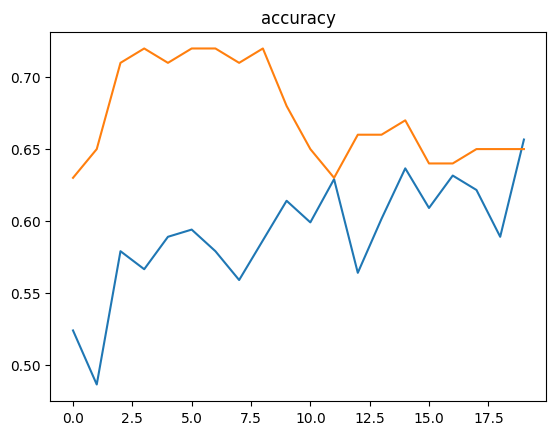

In [11]:
# ploting 

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('accuracy')
plt.show()

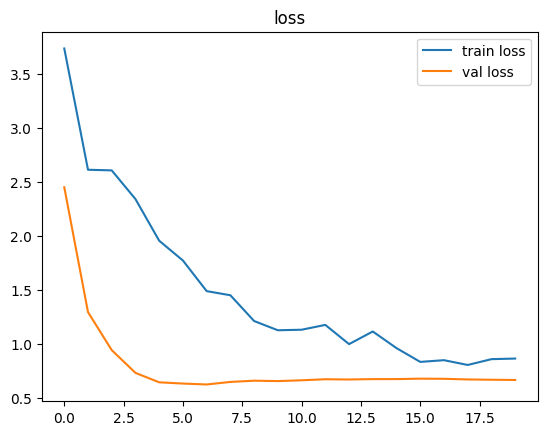

In [15]:
# 
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('loss')
plt.legend()
plt.show()